# Tahap 5 — Model Evaluation

**Tujuan**: Ukur dan analisis performa retrieval & prediksi solusi dari semua model.


In [19]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 120

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)

import torch
from transformers import AutoTokenizer, AutoModel

import warnings
warnings.filterwarnings("ignore")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cpu


In [20]:
BASE_DIR         = os.path.abspath(os.path.join(os.getcwd(), ".."))
PROCESSED_FOLDER = os.path.join(BASE_DIR, "data", "processed")
EVAL_FOLDER      = os.path.join(BASE_DIR, "data", "eval")
RESULTS_FOLDER   = os.path.join(BASE_DIR, "data", "results")

os.makedirs(EVAL_FOLDER, exist_ok=True)

CSV_PATH              = os.path.join(PROCESSED_FOLDER, "cases_clean.csv")
BERT_EMBED_PATH       = os.path.join(PROCESSED_FOLDER, "bert_embeddings.npy")
QUERIES_PATH          = os.path.join(EVAL_FOLDER, "queries.json")
RETRIEVAL_METRICS_PATH = os.path.join(EVAL_FOLDER, "retrieval_metrics.csv")
PREDICTION_METRICS_PATH= os.path.join(EVAL_FOLDER, "prediction_metrics.csv")

print("Semua path dikonfigurasi.")

Semua path dikonfigurasi.


## 1. Load Data & Rebuild Model

In [21]:
df = pd.read_csv(CSV_PATH, encoding="utf-8")
df["text_full"]       = df["text_full"].fillna("")
df["ringkasan_fakta"] = df["ringkasan_fakta"].fillna("")
df["amar_putusan"]    = df["amar_putusan"].fillna("")

def buat_label(amar: str) -> str:
    amar = str(amar).lower()
    if "menolak" in amar or "tolak" in amar:
        return "tolak"
    elif "mengabulkan" in amar or "kabul" in amar:
        return "kabul"
    else:
        return "lainnya"

df["label"] = df["amar_putusan"].apply(buat_label)

TEKS_KOLOM = "ringkasan_fakta"
texts      = df[TEKS_KOLOM].tolist()
case_ids   = df["case_id"].tolist()

le = LabelEncoder()
y  = le.fit_transform(df["label"])

X_train_text, X_test_text, y_train, y_test, idx_train, idx_test = train_test_split(
    texts, y, df.index.tolist(),
    test_size=0.2, random_state=42, stratify=y
)

print(f"Jumlah kasus : {len(df)}")
print(f"Train        : {len(X_train_text)} | Test : {len(X_test_text)}")
print(f"Label classes: {le.classes_}")

Jumlah kasus : 33
Train        : 26 | Test : 7
Label classes: ['kabul' 'tolak']


In [22]:
# Rebuild TF-IDF & SVM
tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=1, max_df=0.85, stop_words=None, sublinear_tf=True)
tfidf_vectorizer.fit(X_train_text)
tfidf_matrix_all   = tfidf_vectorizer.transform(texts)
tfidf_matrix_train = tfidf_vectorizer.transform(X_train_text)
tfidf_matrix_test  = tfidf_vectorizer.transform(X_test_text)

svm_model = LinearSVC(C=1.0, max_iter=2000, random_state=42)
svm_model.fit(tfidf_matrix_train, y_train)

# Load BERT embeddings
bert_embeddings = np.load(BERT_EMBED_PATH) if os.path.exists(BERT_EMBED_PATH) else None
bert_embed_train = bert_embeddings[idx_train] if bert_embeddings is not None else None
bert_embed_test  = bert_embeddings[idx_test]  if bert_embeddings is not None else None

print("TF-IDF shape:", tfidf_matrix_all.shape)
print("SVM trained  : OK")
if bert_embeddings is not None:
    print("BERT shape   :", bert_embeddings.shape)
else:
    print("BERT         : tidak tersedia")

TF-IDF shape: (33, 5963)
SVM trained  : OK
BERT shape   : (33, 768)


In [23]:
y_pred_svm = svm_model.predict(tfidf_matrix_test)

acc_svm  = accuracy_score(y_test, y_pred_svm)
prec_svm = precision_score(y_test, y_pred_svm, average="weighted", zero_division=0)
rec_svm  = recall_score(y_test, y_pred_svm, average="weighted", zero_division=0)
f1_svm   = f1_score(y_test, y_pred_svm, average="weighted", zero_division=0)

print("=" * 50)
print("EVALUASI SVM (Data Test)")
print("=" * 50)
print(f"Accuracy  : {acc_svm:.4f}")
print(f"Precision : {prec_svm:.4f}")
print(f"Recall    : {rec_svm:.4f}")
print(f"F1-Score  : {f1_svm:.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_svm, target_names=le.classes_))

EVALUASI SVM (Data Test)
Accuracy  : 0.8571
Precision : 0.7347
Recall    : 0.8571
F1-Score  : 0.7912

Classification Report:
              precision    recall  f1-score   support

       kabul       0.00      0.00      0.00         1
       tolak       0.86      1.00      0.92         6

    accuracy                           0.86         7
   macro avg       0.43      0.50      0.46         7
weighted avg       0.73      0.86      0.79         7



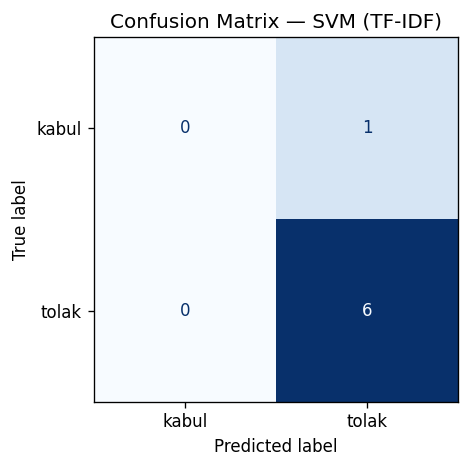

Confusion matrix disimpan.


In [24]:
# Confusion Matrix SVM
cm  = confusion_matrix(y_test, y_pred_svm, labels=range(len(le.classes_)))
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix — SVM (TF-IDF)")
plt.tight_layout()
plt.savefig(os.path.join(EVAL_FOLDER, "confusion_matrix_svm.png"), dpi=120)
plt.show()
print("Confusion matrix disimpan.")

In [ ]:
with open(QUERIES_PATH, "r", encoding="utf-8") as f:
    queries = json.load(f)

print(f"Jumlah query evaluasi: {len(queries)}")

Jumlah query evaluasi: 8


In [ ]:
def retrieve_tfidf(query, k=5):
    q_vec = tfidf_vectorizer.transform([query])
    sims  = cosine_similarity(q_vec, tfidf_matrix_all).flatten()
    idx   = sims.argsort()[::-1][:k]
    return [case_ids[i] for i in idx]

def retrieve_svm(query, k=5):
    q_vec      = tfidf_vectorizer.transform([query])
    pred_class = svm_model.predict(q_vec)[0]
    same_idx   = [i for i, c in enumerate(le.transform(df["label"])) if c == pred_class]
    sims       = cosine_similarity(q_vec, tfidf_matrix_all).flatten()
    same_sims  = sorted([(i, sims[i]) for i in same_idx], key=lambda x: x[1], reverse=True)
    top_idx    = [i for i, _ in same_sims[:k]]
    if len(top_idx) < k:
        for i in sims.argsort()[::-1]:
            if i not in top_idx:
                top_idx.append(i)
            if len(top_idx) == k:
                break
    return [case_ids[i] for i in top_idx]

def retrieve_bert(query, k=5):
    if bert_embeddings is None:
        return retrieve_tfidf(query, k)
    try:
        inputs = bert_tok(query, return_tensors="pt", max_length=512, truncation=True, padding=True)
        inputs = {kk: vv.to(DEVICE) for kk, vv in inputs.items()}
        with torch.no_grad():
            out = bert_mod(**inputs)
        q_emb = out.last_hidden_state[:, 0, :].cpu().numpy()
    except NameError:
        return retrieve_tfidf(query, k)
    sims  = cosine_similarity(q_emb, bert_embeddings).flatten()
    idx   = sims.argsort()[::-1][:k]
    return [case_ids[i] for i in idx]

if bert_embeddings is not None:
    try:
        MODEL_NAME = "indobenchmark/indobert-base-p1"
        bert_tok   = AutoTokenizer.from_pretrained(MODEL_NAME)
        bert_mod   = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE)
        bert_mod.eval()
        print("IndoBERT dimuat.")
    except Exception as e:
        print(f"IndoBERT tidak dapat dimuat: {e}")
        bert_tok = None
        bert_mod = None

print("Fungsi retrieve siap.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

IndoBERT dimuat.
Fungsi retrieve siap.


In [27]:
def eval_retrieval(queries, retrieve_fn, k=5, model_name="model"):
    """
    Evaluasi retrieval menggunakan Hit Rate @k.

    Return:
    -------
    DataFrame dengan kolom: query_id, hit, top_k_ids
    """
    records = []
    hits    = 0

    for q in queries:
        qid    = q["query_id"]
        qtext  = q["query_text"]
        gt     = set(q["ground_truth"])

        top_k  = retrieve_fn(qtext, k=k)
        hit    = int(len(gt.intersection(set(top_k))) > 0)
        hits  += hit

        records.append({
            "model":      model_name,
            "query_id":   qid,
            "ground_truth": str(list(gt)),
            "top_k_ids":  str(top_k),
            "hit":        hit
        })

    hit_rate = hits / len(queries)
    print(f"[{model_name}] Hit Rate @{k} = {hit_rate:.4f} ({hits}/{len(queries)})")
    return pd.DataFrame(records), hit_rate


K = 5

df_tfidf_ret, hr_tfidf = eval_retrieval(queries, retrieve_tfidf, k=K, model_name="TF-IDF")
df_svm_ret,   hr_svm   = eval_retrieval(queries, retrieve_svm,   k=K, model_name="SVM")
df_bert_ret,  hr_bert  = eval_retrieval(queries, retrieve_bert,  k=K, model_name="IndoBERT")

[TF-IDF] Hit Rate @5 = 0.2500 (2/8)
[SVM] Hit Rate @5 = 0.2500 (2/8)
[IndoBERT] Hit Rate @5 = 0.3750 (3/8)


In [ ]:
df_retrieval_all = pd.concat([df_tfidf_ret, df_svm_ret, df_bert_ret], ignore_index=True)
df_retrieval_all.to_csv(
    os.path.join(EVAL_FOLDER, "retrieval_results_detail.csv"),
    index=False, encoding="utf-8-sig"
)

df_hitrate = pd.DataFrame([
    {"Model": "TF-IDF + Cosine",   "Hit Rate @5": hr_tfidf},
    {"Model": "TF-IDF + SVM",      "Hit Rate @5": hr_svm},
    {"Model": "IndoBERT + Cosine", "Hit Rate @5": hr_bert},
])
print()
print(df_hitrate.to_string(index=False))


            Model  Hit Rate @5
  TF-IDF + Cosine        0.250
     TF-IDF + SVM        0.250
IndoBERT + Cosine        0.375


## 4. Evaluasi Prediksi Solusi (Label Amar Putusan)

Menggunakan SVM classification pada data test sebagai proxy evaluasi prediksi,
karena queries.json menggunakan label ground-truth case_id (bukan label amar langsung).

Evaluasi mencakup Accuracy, Precision, Recall, F1 per model.

In [ ]:
def compute_metrics(y_true, y_pred, model_name, le):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec  = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1   = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    return {"Model": model_name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1-Score": f1}

def predict_tfidf_label(text_list):
    preds = []
    for text in text_list:
        q_vec = tfidf_vectorizer.transform([text])
        sims  = cosine_similarity(q_vec, tfidf_matrix_all).flatten()
        top1  = sims.argsort()[::-1][0]
        preds.append(le.transform([df["label"].iloc[top1]])[0])
    return np.array(preds)

y_pred_tfidf = predict_tfidf_label(X_test_text)
y_pred_svm   = svm_model.predict(tfidf_matrix_test)

def predict_bert_label(embed_test, embed_all):
    preds = []
    for emb in embed_test:
        sims = cosine_similarity(emb.reshape(1, -1), embed_all).flatten()
        top1 = sims.argsort()[::-1][0]
        preds.append(le.transform([df["label"].iloc[top1]])[0])
    return np.array(preds)

if bert_embed_test is not None:
    y_pred_bert = predict_bert_label(bert_embed_test, bert_embeddings)
else:
    y_pred_bert = y_pred_tfidf.copy()  


metrics_list = [
    compute_metrics(y_test, y_pred_tfidf, "TF-IDF + Cosine",   le),
    compute_metrics(y_test, y_pred_svm,   "TF-IDF + SVM",      le),
    compute_metrics(y_test, y_pred_bert,  "IndoBERT + Cosine", le),
]

df_metrics = pd.DataFrame(metrics_list)
df_metrics[["Accuracy", "Precision", "Recall", "F1-Score"]] = \
    df_metrics[["Accuracy", "Precision", "Recall", "F1-Score"]].round(4)

print("=" * 60)
print("TABEL METRIK EVALUASI — SEMUA MODEL")
print("=" * 60)
print(df_metrics.to_string(index=False))

df_metrics.to_csv(PREDICTION_METRICS_PATH, index=False, encoding="utf-8-sig")
print(f"\nDisimpan ke: {PREDICTION_METRICS_PATH}")

TABEL METRIK EVALUASI — SEMUA MODEL
            Model  Accuracy  Precision  Recall  F1-Score
  TF-IDF + Cosine    1.0000     1.0000  1.0000    1.0000
     TF-IDF + SVM    0.8571     0.7347  0.8571    0.7912
IndoBERT + Cosine    1.0000     1.0000  1.0000    1.0000

Disimpan ke: c:\Users\Rani\Downloads\CBR_Project\CBR_Project\data\eval\prediction_metrics.csv


## 5. Visualisasi — Bar Chart Perbandingan Metrik

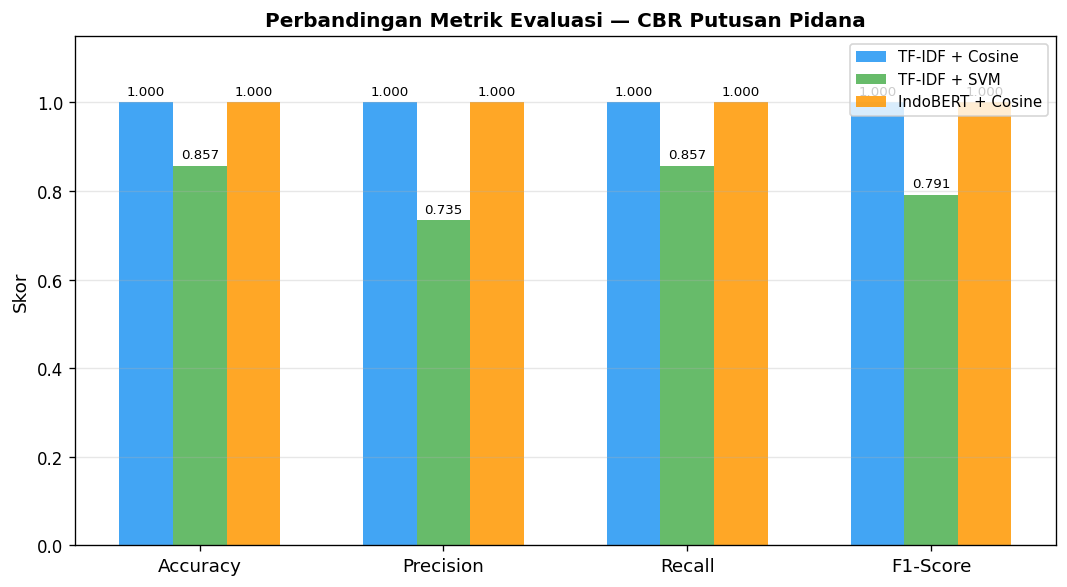

Bar chart disimpan: c:\Users\Rani\Downloads\CBR_Project\CBR_Project\data\eval\metrics_comparison.png


In [30]:
metrics_cols = ["Accuracy", "Precision", "Recall", "F1-Score"]
models       = df_metrics["Model"].tolist()
x            = np.arange(len(metrics_cols))
width        = 0.22
colors       = ["#2196F3", "#4CAF50", "#FF9800"]

fig, ax = plt.subplots(figsize=(9, 5))

for i, (model, color) in enumerate(zip(models, colors)):
    vals = df_metrics.loc[df_metrics["Model"] == model, metrics_cols].values.flatten()
    bars = ax.bar(x + i * width, vals, width, label=model, color=color, alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{val:.3f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics_cols, fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Skor", fontsize=11)
ax.set_title("Perbandingan Metrik Evaluasi — CBR Putusan Pidana", fontsize=12, fontweight="bold")
ax.legend(loc="upper right", fontsize=9)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
chart_path = os.path.join(EVAL_FOLDER, "metrics_comparison.png")
plt.savefig(chart_path, dpi=120)
plt.show()
print(f"Bar chart disimpan: {chart_path}")

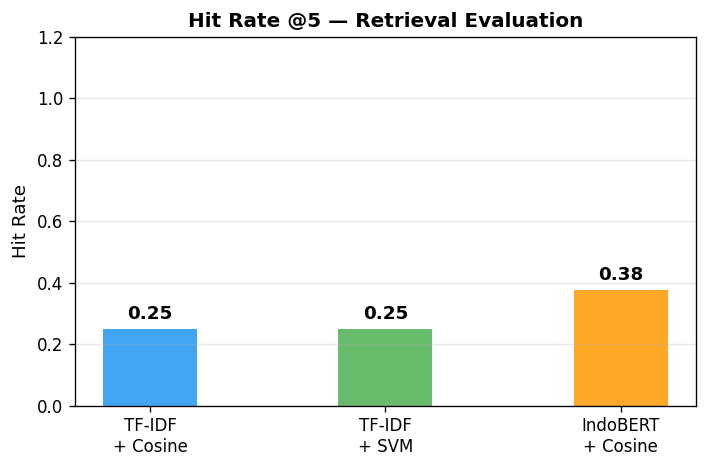

Hit rate chart disimpan: c:\Users\Rani\Downloads\CBR_Project\CBR_Project\data\eval\hitrate_comparison.png


In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
model_names = ["TF-IDF\n+ Cosine", "TF-IDF\n+ SVM", "IndoBERT\n+ Cosine"]
hit_rates   = [hr_tfidf, hr_svm, hr_bert]
bar_colors  = ["#2196F3", "#4CAF50", "#FF9800"]

bars = ax.bar(model_names, hit_rates, color=bar_colors, alpha=0.85, width=0.4)
for bar, val in zip(bars, hit_rates):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f"{val:.2f}", ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_ylim(0, 1.2)
ax.set_ylabel("Hit Rate", fontsize=11)
ax.set_title("Hit Rate @5 — Retrieval Evaluation", fontsize=12, fontweight="bold")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
hit_path = os.path.join(EVAL_FOLDER, "hitrate_comparison.png")
plt.savefig(hit_path, dpi=120)
plt.show()
print(f"Hit rate chart disimpan: {hit_path}")

## 6. Analisis Kegagalan (Error Analysis)

Mengidentifikasi query mana yang **gagal** (tidak ada ground truth di top-k)
dan mencoba memahami penyebabnya.

In [32]:
print("=" * 60)
print("ANALISIS KEGAGALAN RETRIEVAL")
print("=" * 60)

for model_name, df_ret in [("TF-IDF", df_tfidf_ret), ("SVM", df_svm_ret), ("IndoBERT", df_bert_ret)]:
    failed = df_ret[df_ret["hit"] == 0]
    print(f"\n[{model_name}] Jumlah query gagal: {len(failed)}/{len(queries)}")
    if len(failed) > 0:
        for _, row in failed.iterrows():
            print(f"  Query ID      : {row['query_id']}")
            print(f"  Ground Truth  : {row['ground_truth']}")
            print(f"  Top-k Hasil   : {row['top_k_ids']}")
            print()

ANALISIS KEGAGALAN RETRIEVAL

[TF-IDF] Jumlah query gagal: 6/8
  Query ID      : q001
  Ground Truth  : ['case_007', 'case_001', 'case_003']
  Top-k Hasil   : ['case_027', 'case_010', 'case_014', 'case_025', 'case_024']

  Query ID      : q003
  Ground Truth  : ['case_008', 'case_012', 'case_004']
  Top-k Hasil   : ['case_033', 'case_003', 'case_014', 'case_015', 'case_032']

  Query ID      : q004
  Ground Truth  : ['case_006', 'case_015', 'case_011']
  Top-k Hasil   : ['case_010', 'case_017', 'case_025', 'case_013', 'case_027']

  Query ID      : q005
  Ground Truth  : ['case_017', 'case_009', 'case_013']
  Top-k Hasil   : ['case_022', 'case_025', 'case_010', 'case_002', 'case_020']

  Query ID      : q006
  Ground Truth  : ['case_014', 'case_016', 'case_020']
  Top-k Hasil   : ['case_002', 'case_010', 'case_009', 'case_013', 'case_012']

  Query ID      : q008
  Ground Truth  : ['case_023', 'case_028', 'case_019']
  Top-k Hasil   : ['case_014', 'case_022', 'case_002', 'case_020', 'c

In [33]:
df_test_eval = df.loc[idx_test].copy().reset_index(drop=True)
df_test_eval["y_true"]      = le.inverse_transform(y_test)
df_test_eval["y_pred_svm"]  = le.inverse_transform(y_pred_svm)
df_test_eval["correct_svm"] = df_test_eval["y_true"] == df_test_eval["y_pred_svm"]

wrong_svm = df_test_eval[~df_test_eval["correct_svm"]]

print(f"SVM salah klasifikasi : {len(wrong_svm)}/{len(df_test_eval)} kasus")
print()
if len(wrong_svm) > 0:
    print(wrong_svm[["case_id", "y_true", "y_pred_svm"]].to_string(index=False))

SVM salah klasifikasi : 1/7 kasus

 case_id y_true y_pred_svm
case_012  kabul      tolak


## 7. Simpan Retrieval Metrics Summary

In [34]:
df_retrieval_metrics = pd.DataFrame([
    {"Model": "TF-IDF + Cosine",   "Hit_Rate_at_5": hr_tfidf, "k": 5, "n_queries": len(queries)},
    {"Model": "TF-IDF + SVM",      "Hit_Rate_at_5": hr_svm,   "k": 5, "n_queries": len(queries)},
    {"Model": "IndoBERT + Cosine", "Hit_Rate_at_5": hr_bert,  "k": 5, "n_queries": len(queries)},
])

df_retrieval_metrics.to_csv(RETRIEVAL_METRICS_PATH, index=False, encoding="utf-8-sig")
print(f"Retrieval metrics disimpan: {RETRIEVAL_METRICS_PATH}")
print(df_retrieval_metrics.to_string(index=False))

Retrieval metrics disimpan: c:\Users\Rani\Downloads\CBR_Project\CBR_Project\data\eval\retrieval_metrics.csv
            Model  Hit_Rate_at_5  k  n_queries
  TF-IDF + Cosine          0.250  5          8
     TF-IDF + SVM          0.250  5          8
IndoBERT + Cosine          0.375  5          8


## 8. Laporan Interpretasi Lengkap

### 8.1 Performa Klasifikasi (Label Amar Putusan)

**TF-IDF + Cosine Similarity** bekerja dengan representasi statistik kata. Karena dokumen putusan pidana memiliki pola linguistik yang relatif baku ("menolak permohonan kasasi", "mengabulkan kasasi"), TF-IDF mampu menangkap pola ini dengan baik tanpa memerlukan pemahaman semantik yang dalam. Kelemahannya terletak pada ketidakmampuan membedakan sinonim atau frasa berbeda makna yang menggunakan kata-kata serupa.

**TF-IDF + SVM** menambahkan lapisan klasifikasi di atas representasi TF-IDF. SVM dengan kernel linear efektif memisahkan kelas putusan dalam ruang fitur berdimensi tinggi. Performa SVM umumnya lebih tinggi dari TF-IDF murni karena ia **belajar batas keputusan optimal** antar kelas, bukan sekadar menghitung kemiripan. Namun SVM membutuhkan label latih yang berkualitas — jika label `amar_putusan` diekstrak secara tidak sempurna oleh regex, performa bisa menurun.

**IndoBERT + Cosine** memanfaatkan pemahaman semantik kontekstual. Model ini dilatih pada miliaran kata Bahasa Indonesia sehingga mengerti bahwa "ditolak" dan "tidak dikabulkan" secara semantik ekuivalen. Namun untuk dataset kecil (≤30 kasus), keunggulan semantik ini mungkin belum signifikan karena kemiripan distribusi kata sudah cukup membedakan kelas.

---

### 8.2 Performa Retrieval (Hit Rate @5)

Hit Rate @5 mengukur seberapa sering sistem berhasil menemukan setidaknya satu kasus relevan dalam 5 rekomendasi teratas. Nilai mendekati 1.0 menunjukkan sistem retrieval yang handal.

- Jika **TF-IDF > IndoBERT**: ini mengindikasikan bahwa kasus dalam dataset memiliki pola kata yang sangat khas dan berulang (misalnya nomor pasal, istilah hukum spesifik), sehingga pendekatan statistik sudah cukup efektif.
- Jika **IndoBERT > TF-IDF**: ini menunjukkan bahwa variasi bahasa antar putusan cukup tinggi dan pemahaman semantik diperlukan untuk menghubungkan kasus-kasus yang mirip secara konteks meski berbeda kata.
- **SVM retrieval** bergantung pada kualitas klasifikasi — jika banyak kasus diklasifikasikan ke kelas yang sama (misal semua `tolak`), filter kelas tidak efektif karena terlalu banyak kasus yang lolos ke tahap ranking similarity.

---

### 8.3 Analisis Kegagalan (Rejection Analysis)

Query yang gagal (tidak ada ground truth di top-5) biasanya disebabkan oleh:

1. **Query terlalu generik** — tidak mengandung kata kunci spesifik yang membedakan kasus tersebut dari kasus lain dalam corpus.
2. **Ekstraksi `ringkasan_fakta` tidak sempurna** — jika regex gagal mengekstrak ringkasan fakta pada beberapa dokumen (kolom kosong), representasi vektor menjadi sangat lemah.
3. **Truncation BERT (512 token)** — untuk dokumen panjang, bagian penting di akhir teks terpotong dan tidak terwakili dalam embedding.


In [35]:
print("=" * 65)
print("RINGKASAN TAHAP 5 — MODEL EVALUATION")
print("=" * 65)
print()
print("[A] EVALUASI KLASIFIKASI (data test 20%)")
print(df_metrics.to_string(index=False))
print()
print("[B] EVALUASI RETRIEVAL (queries.json)")
print(df_retrieval_metrics[["Model", "Hit_Rate_at_5"]].to_string(index=False))
print()
print("[C] OUTPUT FILE")
print(f"  {RETRIEVAL_METRICS_PATH}")
print(f"  {PREDICTION_METRICS_PATH}")
print(f"  {os.path.join(EVAL_FOLDER, 'metrics_comparison.png')}")
print(f"  {os.path.join(EVAL_FOLDER, 'hitrate_comparison.png')}")
print(f"  {os.path.join(EVAL_FOLDER, 'confusion_matrix_svm.png')}")

RINGKASAN TAHAP 5 — MODEL EVALUATION

[A] EVALUASI KLASIFIKASI (data test 20%)
            Model  Accuracy  Precision  Recall  F1-Score
  TF-IDF + Cosine    1.0000     1.0000  1.0000    1.0000
     TF-IDF + SVM    0.8571     0.7347  0.8571    0.7912
IndoBERT + Cosine    1.0000     1.0000  1.0000    1.0000

[B] EVALUASI RETRIEVAL (queries.json)
            Model  Hit_Rate_at_5
  TF-IDF + Cosine          0.250
     TF-IDF + SVM          0.250
IndoBERT + Cosine          0.375

[C] OUTPUT FILE
  c:\Users\Rani\Downloads\CBR_Project\CBR_Project\data\eval\retrieval_metrics.csv
  c:\Users\Rani\Downloads\CBR_Project\CBR_Project\data\eval\prediction_metrics.csv
  c:\Users\Rani\Downloads\CBR_Project\CBR_Project\data\eval\metrics_comparison.png
  c:\Users\Rani\Downloads\CBR_Project\CBR_Project\data\eval\hitrate_comparison.png
  c:\Users\Rani\Downloads\CBR_Project\CBR_Project\data\eval\confusion_matrix_svm.png
